In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("US_Accidents_march23.csv", nrows=100000)

In [6]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [7]:
df.shape

(100000, 46)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  str    
 1   Source                 100000 non-null  str    
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  str    
 4   End_Time               100000 non-null  str    
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  str    
 11  Street                 100000 non-null  str    
 12  City                   99999 non-null   str    
 13  County                 100000 non-null  str    
 14  State                  100000 non-null  str    


In [9]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,100000.000000,100000.000000,100000.000000,0.0,0.0,100000.000000,98409.000000,4322.000000,98144.000000,98708.000000,98154.000000,76180.000000,7368.000000
mean,2.448120,35.630369,-119.322756,NaN,NaN,0.011345,66.641262,48.845812,59.794170,29.961021,9.338639,8.044165,0.025786
std,0.499931,2.101259,3.663525,NaN,NaN,0.262244,12.703846,19.898270,23.184442,0.275672,1.885828,4.298926,0.051695
min,1.000000,32.542587,-123.813927,NaN,NaN,0.000000,3.200000,-8.400000,4.000000,2.980000,0.100000,0.000000,0.000000
25%,2.000000,33.957775,-121.828468,NaN,NaN,0.000000,57.900000,37.100000,43.000000,29.890000,10.000000,4.600000,0.000000
50%,2.000000,34.168579,-118.384232,NaN,NaN,0.000000,66.000000,42.500000,62.000000,29.970000,10.000000,6.900000,0.000000
75%,3.000000,37.776682,-117.916023,NaN,NaN,0.010000,75.000000,63.000000,78.000000,30.060000,10.000000,10.400000,0.030000
max,4.000000,41.428753,-81.550728,NaN,NaN,51.130000,114.100000,107.000000,100.000000,33.040000,80.000000,241.700000,0.550000


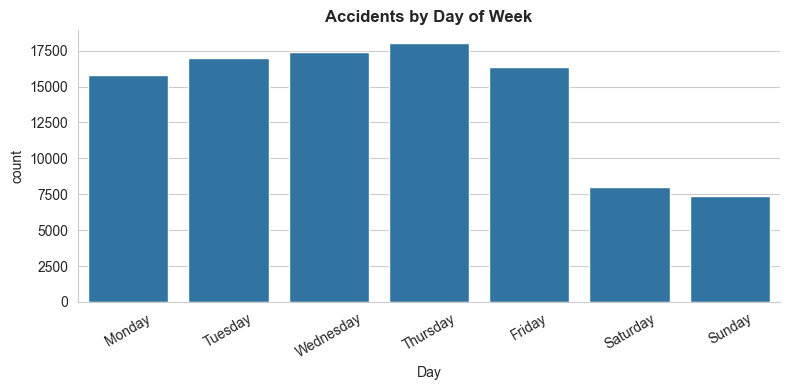

In [16]:
# Convert to datetime FIRST (this fixes your error)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

# Now extract day safely
df['Day'] = df['Start_Time'].dt.day_name()

# Plot
plt.figure(figsize=(8,4))

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.countplot(x='Day', data=df, order=order)

plt.title("Accidents by Day of Week", weight='bold')
plt.xticks(rotation=30)

sns.despine()
plt.tight_layout()
plt.show()

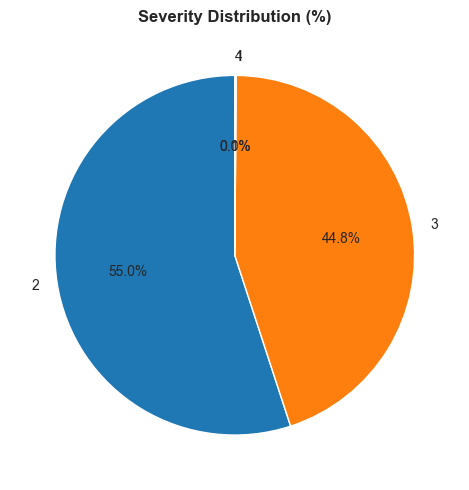

In [17]:
counts = df['Severity'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(counts, labels=counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Severity Distribution (%)", weight='bold')

plt.tight_layout()
plt.show()

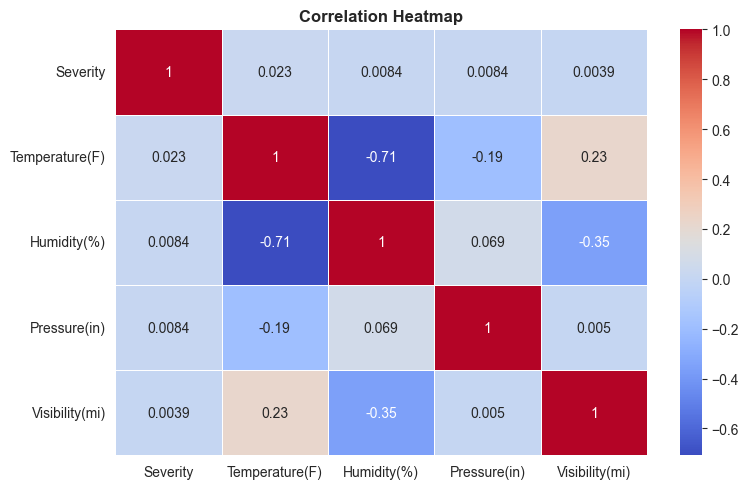

In [18]:
plt.figure(figsize=(8,5))

corr = df[['Severity','Temperature(F)','Humidity(%)','Pressure(in)','Visibility(mi)']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap", weight='bold')

plt.tight_layout()
plt.show()

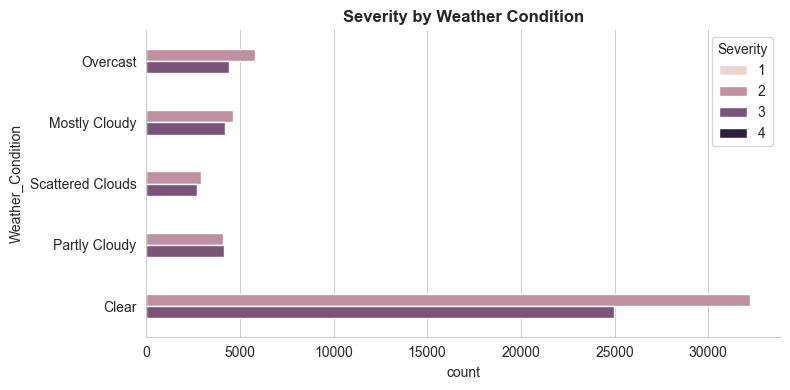

In [20]:
top_weather = df['Weather_Condition'].value_counts().head(5).index

plt.figure(figsize=(8,4))

sns.countplot(data=df[df['Weather_Condition'].isin(top_weather)],
              y='Weather_Condition',
              hue='Severity')

plt.title("Severity by Weather Condition", weight='bold')

sns.despine()
plt.tight_layout()
plt.show()

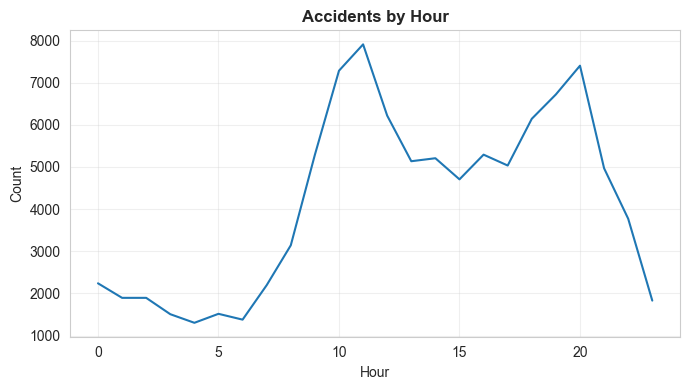

In [21]:
hour_counts = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(7,4))

plt.plot(hour_counts.index, hour_counts.values)

plt.title("Accidents by Hour", weight='bold')
plt.xlabel("Hour")
plt.ylabel("Count")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

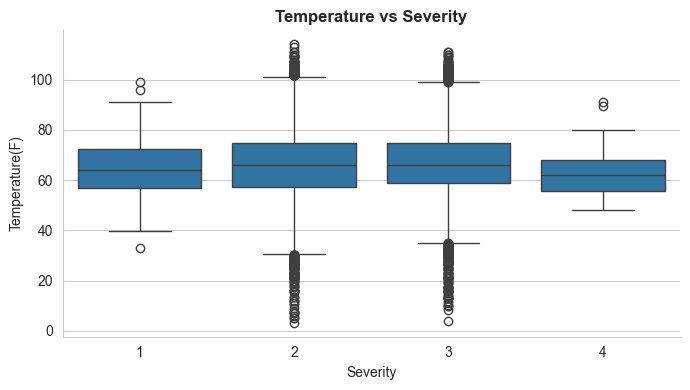

In [22]:
plt.figure(figsize=(7,4))

sns.boxplot(x='Severity', y='Temperature(F)', data=df)

plt.title("Temperature vs Severity", weight='bold')

sns.despine()
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

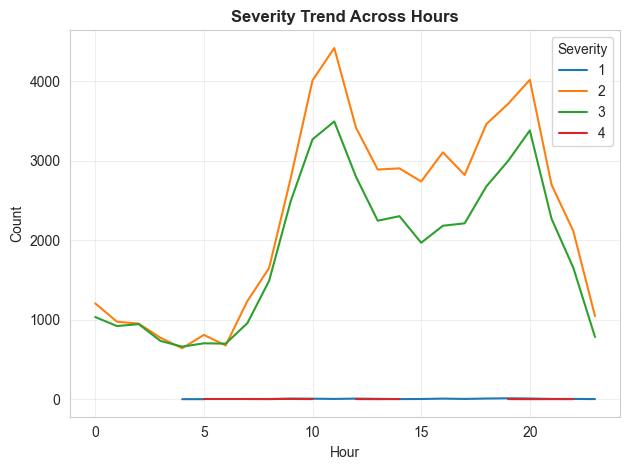

In [24]:
severity_hour = df.groupby(['Hour','Severity']).size().unstack()

plt.figure(figsize=(8,4))

severity_hour.plot()

plt.title("Severity Trend Across Hours", weight='bold')
plt.xlabel("Hour")
plt.ylabel("Count")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

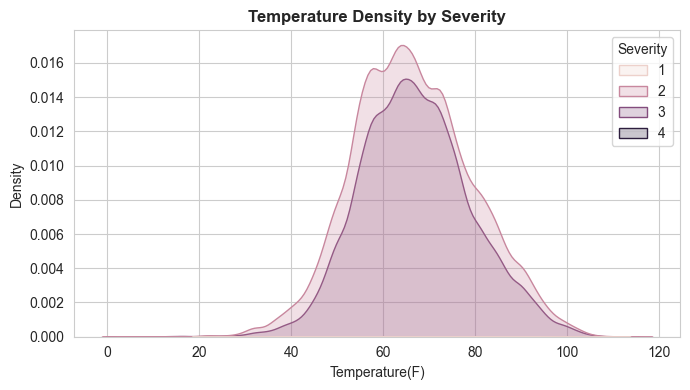

In [25]:
plt.figure(figsize=(7,4))

sns.kdeplot(data=df, x='Temperature(F)', hue='Severity', fill=True)

plt.title("Temperature Density by Severity", weight='bold')

plt.tight_layout()
plt.show()

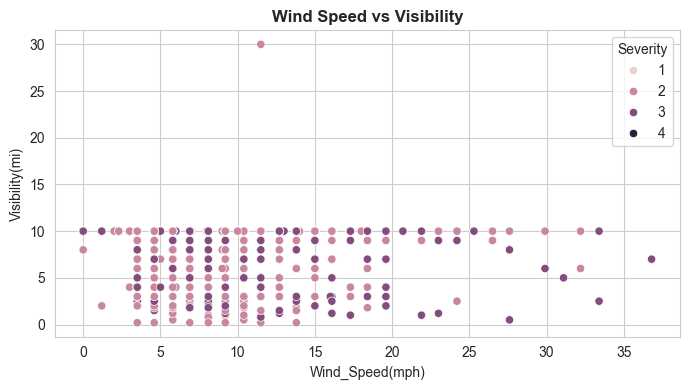

In [26]:
plt.figure(figsize=(7,4))

sns.scatterplot(x='Wind_Speed(mph)', y='Visibility(mi)',
                hue='Severity', data=df.sample(5000))

plt.title("Wind Speed vs Visibility", weight='bold')

plt.tight_layout()
plt.show()

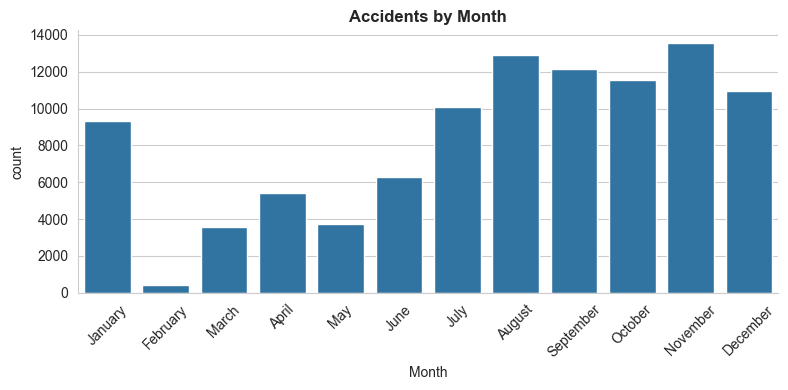

In [27]:
df['Month'] = df['Start_Time'].dt.month_name()

plt.figure(figsize=(8,4))

order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']

sns.countplot(x='Month', data=df, order=order)

plt.xticks(rotation=45)
plt.title("Accidents by Month", weight='bold')

sns.despine()
plt.tight_layout()
plt.show()